In [1]:
# Cell 1: Install packages in current kernel (run once)
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "joblib"
])
print("Packages are installed in this kernel.")

Packages are installed in this kernel.


In [2]:
# Debug setup
import os
import sys
print(sys.executable)
print("exists:", os.path.exists(sys.executable))
print(sys.version)

c:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe
exists: True
3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [3]:
# Cell 2: Imports
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Imports loaded successfully")

Imports loaded successfully


In [4]:
# Cell 3: Load processed data (use SCALED features for KNN)
X_train = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test  = pd.read_csv("../data/processed/X_test_scaled.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("=== Data loaded successfully ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print("\nClass distribution (train):")
print(y_train.value_counts())

=== Data loaded successfully ===
X_train shape: (27532, 14)
X_test shape:  (6519, 14)
y_train shape: (27532,)
y_test shape:  (6519,)

Class distribution (train):
dropout
1    13766
0    13766
Name: count, dtype: int64


In [5]:
# Cell 4: Train + tune KNN with GridSearchCV
param_grid = {
    "n_neighbors": list(range(3, 32, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
knn_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'uniform'}
Best CV ROC-AUC: 0.9581


In [6]:
# Cell 5: Evaluate model + Overfitting check

# Test predictions
y_pred = knn_model.predict(X_test)
y_proba = knn_model.predict_proba(X_test)[:, 1]

# Train predictions
y_train_pred = knn_model.predict(X_train)

# Metrics (Test)
test_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

# Training accuracy
train_acc = accuracy_score(y_train, y_train_pred)

print("=== MODEL EVALUATION RESULTS ===\n")

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy : {test_acc:.4f}")

gap = train_acc - test_acc
print(f"Accuracy Gap     : {gap:.4f}")
print()

# Interpretation
if gap > 0.05:
    print("Model is likely OVERFITTING")
elif gap < 0.02:
    print("Model generalizes VERY WELL")
else:
    print(" Model generalization is ACCEPTABLE")

print("\n=== TEST METRICS ===")
print("Accuracy :", round(test_acc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc, 4))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

=== MODEL EVALUATION RESULTS ===

Training Accuracy: 0.8926
Testing Accuracy : 0.8885
Accuracy Gap     : 0.0042

Model generalizes VERY WELL

=== TEST METRICS ===
Accuracy : 0.8885
Precision: 0.9322
Recall   : 0.8507
F1-score : 0.8896
ROC-AUC  : 0.96

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      3077
           1       0.93      0.85      0.89      3442

    accuracy                           0.89      6519
   macro avg       0.89      0.89      0.89      6519
weighted avg       0.89      0.89      0.89      6519



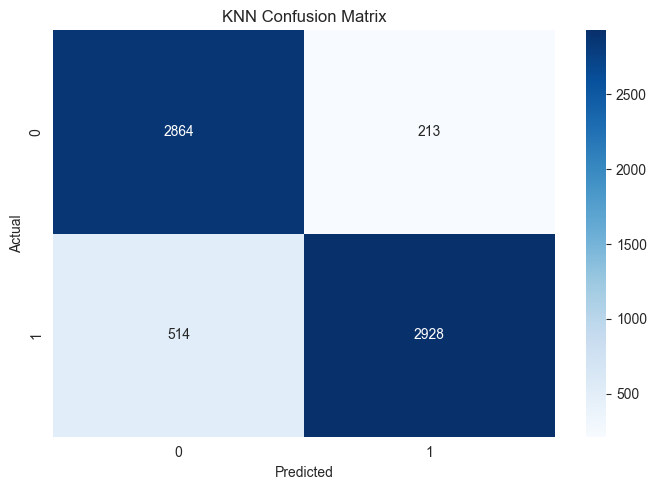

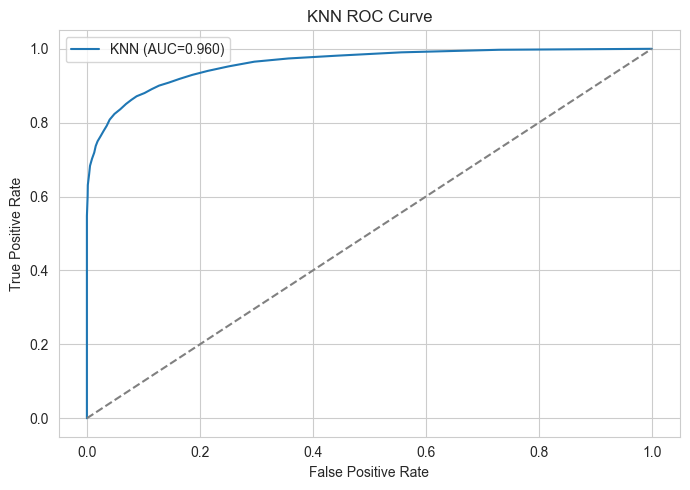

In [7]:
# Cell 6: Confusion matrix and ROC curve
os.makedirs("../report", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../report/03_knn_confusion_matrix.png", dpi=200)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"KNN (AUC={auc_score:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../report/03_knn_roc_curve.png", dpi=200)
plt.show()

                 feature  importance
13        withdrew_early    0.079740
9            total_score    0.013734
10      submission_count    0.013411
6            days_active    0.010372
11             min_score    0.007396
4        studied_credits    0.003157
8              avg_score    0.002585
7       avg_daily_clicks    0.002525
3   num_of_prev_attempts    0.002512
0      highest_education    0.000642


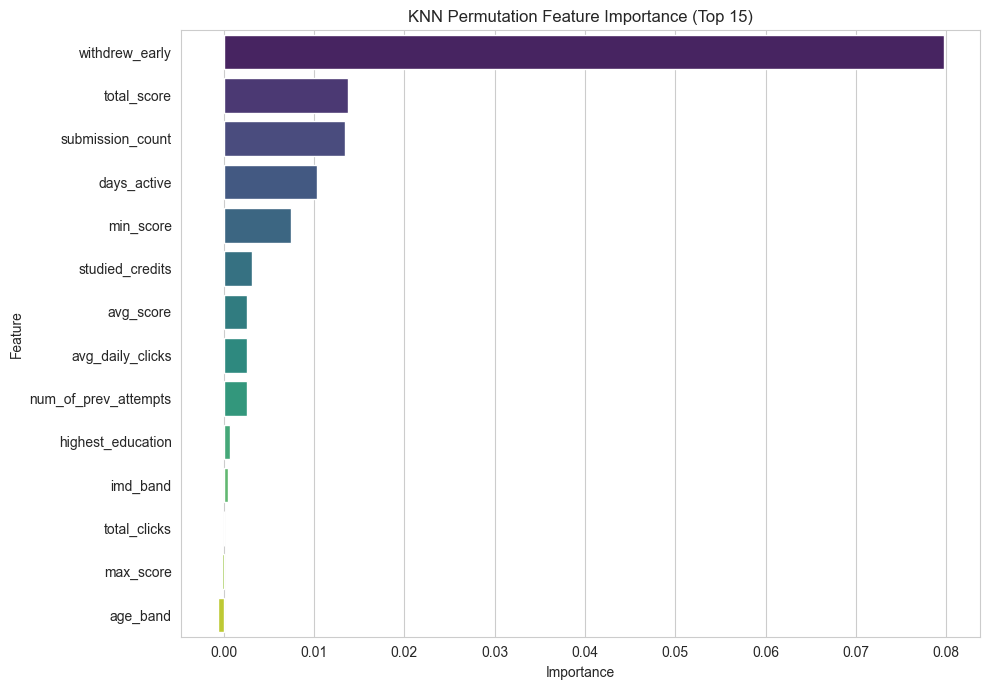

In [8]:
# Cell 7: Permutation feature importance
result = permutation_importance(
    knn_model, X_test, y_test,
    n_repeats=20, random_state=42, scoring="f1", n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", palette="viridis")
plt.title("KNN Permutation Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../report/03_knn_feature_importance.png", dpi=200)
plt.show()

In [9]:
# Cell 8: Save model
joblib.dump(knn_model, "../report/03_knn_model.joblib")
print("Saved model: ../report/03_knn_model.joblib")

Saved model: ../report/03_knn_model.joblib
